In [1]:
# --- Importações Essenciais ---
import os
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

# --- Importações do Scikit-learn, Imbalanced-learn e XGBoost ---
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy import sparse
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    average_precision_score
)

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- Funções Auxiliares ---
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Adicionar checagem para evitar divisão por zero se não houver negativos reais
    if (tn + fp) == 0:
        return 1.0
    return tn / (tn + fp)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# Definir o caminho para os dados processados
processed_data_path = '../../data/processed/cidds_dataset'
train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')

# Carregar os arrays NumPy
train_data = np.load(train_proc_path, allow_pickle=True)
test_data = np.load(test_proc_path, allow_pickle=True)
X_test = test_data['X'].item()
y_test = test_data['y']
X_full = train_data['X'].item()
y_full = train_data['y']

print(f"Formato do dataset completo (X): {X_full.shape}")
print(f"Formato do dataset completo (y): {y_full.shape}")
print("---")

# **Divisão Estratégica em Treino, Validação e Teste**
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=(1/7),  # Aproximadamente 14.28%, que corresponde a 10% do dataset total.
    random_state=42,
    stratify=y_full
)

# Verificar as dimensões finais
print("Divisão final dos dados (sem vstack):")
print(f"Treino (X, y):    \t{X_train.shape}, {y_train.shape}")
print(f"Validação (X, y): \t{X_val.shape}, {y_val.shape}")
print(f"Teste (X, y):     \t{X_test.shape}, {y_test.shape}")

X_train_pca = X_train
X_val_pca   = X_val
X_test_pca  = X_test

Formato do dataset completo (X): (95029, 294)
Formato do dataset completo (y): (95029,)
---
Divisão final dos dados (sem vstack):
Treino (X, y):    	(81453, 294), (81453,)
Validação (X, y): 	(13576, 294), (13576,)
Teste (X, y):     	(56303, 294), (56303,)


In [3]:
# Aplicar SMOTE apenas no conjunto de treino para evitar data leakage
print("--- ANTES DO SMOTE ---")
counts = np.bincount(y_train)
print(f"Distribuição em y_train: {counts}")

smote = SMOTE(random_state=42)
#-- X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)
X_train_resampled, y_train_resampled = X_train_pca, y_train

print("\n--- DEPOIS DO SMOTE ---")
print(f"Formato de X_train_resampled: {X_train_resampled.shape}")
print(f"Distribuição em y_train_resampled: {np.bincount(y_train_resampled)}")

# Calcular scale_pos_weight para o XGBoost
# N amostras classe negativa (0) / N amostras classe positiva (1) - ou o inverso dependendo da codificação
# No nosso caso, Anomalia=1 (maj), Normal=0 (min). XGBoost espera (N_negativos / N_positivos)
if counts[1] > 0:
    scale_pos_weight_value = counts[0] / counts[1]
    print(f"\nValor calculado para scale_pos_weight: {scale_pos_weight_value:.4f}")
else:
    scale_pos_weight_value = 1
    print("\nNão foi possível calcular scale_pos_weight, usando valor padrão 1.")

--- ANTES DO SMOTE ---
Distribuição em y_train: [21235 60218]

--- DEPOIS DO SMOTE ---
Formato de X_train_resampled: (81453, 294)
Distribuição em y_train_resampled: [21235 60218]

Valor calculado para scale_pos_weight: 0.3526


In [4]:
# Grade de hiperparâmetros a ser explorada para o XGBoost
param_grid = {
    'n_estimators': [250, 300, 350],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.005, 0.008, 0.01],
    'gamma': [0, 0.1]
}

# Número de repetições para cada combinação
n_repeats = 1  # Reduzido para um tuning mais rápido

# Lista para armazenar os resultados de cada execução
results_list = []

print("Grade de parâmetros do XGBoost e número de repetições definidos.")

Grade de parâmetros do XGBoost e número de repetições definidos.


In [5]:
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 1.0

total_runs = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['gamma']) * n_repeats
current_run = 0

print(f"Iniciando a busca em grade para XGBoost... Total de {total_runs} execuções.")

# Loop sobre cada combinação de hiperparâmetro
for n_est in param_grid['n_estimators']:
    for m_depth in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:
            for g in param_grid['gamma']:
                # Loop para as repetições
                for i in range(n_repeats):
                    current_run += 1
                    print(f"Execução {current_run}/{total_runs}: n_est={n_est}, max_depth={m_depth}, lr={lr}, gamma={g}, rep={i+1}")

                    # Instanciar o modelo XGBoost
                    model = XGBClassifier(
                        n_estimators=n_est,
                        max_depth=m_depth,
                        learning_rate=lr,
                        gamma=g,
                        scale_pos_weight=scale_pos_weight_value,
                        random_state=i,
                        n_jobs=-1,
                        eval_metric='logloss' # <--- use_label_encoder removido
                    )

                    # Treinar o modelo e medir o tempo
                    start_time = time.time()
                    model.fit(X_train_resampled, y_train_resampled)
                    end_time = time.time()
                    train_time = end_time - start_time

                    # Fazer previsões no conjunto de validação
                    y_pred_val = model.predict(X_val_pca)

                    # Calcular as métricas
                    f1 = f1_score(y_val, y_pred_val)
                    precision = precision_score(y_val, y_pred_val, zero_division=0)
                    recall = recall_score(y_val, y_pred_val, zero_division=0)
                    specificity = calculate_specificity(y_val, y_pred_val)
                    try:
                        roc_auc = roc_auc_score(y_val, y_pred_val)
                        pr_auc = average_precision_score(y_val, y_pred_val)
                    except ValueError:
                        roc_auc = 0
                        pr_auc = 0

                    # Armazenar os resultados
                    results_list.append({
                        'n_estimators': n_est,
                        'max_depth': m_depth,
                        'learning_rate': lr,
                        'gamma': g,
                        'repetition': i + 1,
                        'train_time': train_time,
                        'f1_score': f1,
                        'precision': precision,
                        'recall': recall,
                        'specificity': specificity,
                        'roc_auc': roc_auc,
                        'pr_auc': pr_auc
                    })

print("\nBusca em grade para XGBoost concluída!")

Iniciando a busca em grade para XGBoost... Total de 54 execuções.
Execução 1/54: n_est=250, max_depth=3, lr=0.005, gamma=0, rep=1
Execução 2/54: n_est=250, max_depth=3, lr=0.005, gamma=0.1, rep=1
Execução 3/54: n_est=250, max_depth=3, lr=0.008, gamma=0, rep=1
Execução 4/54: n_est=250, max_depth=3, lr=0.008, gamma=0.1, rep=1
Execução 5/54: n_est=250, max_depth=3, lr=0.01, gamma=0, rep=1
Execução 6/54: n_est=250, max_depth=3, lr=0.01, gamma=0.1, rep=1
Execução 7/54: n_est=250, max_depth=5, lr=0.005, gamma=0, rep=1
Execução 8/54: n_est=250, max_depth=5, lr=0.005, gamma=0.1, rep=1
Execução 9/54: n_est=250, max_depth=5, lr=0.008, gamma=0, rep=1
Execução 10/54: n_est=250, max_depth=5, lr=0.008, gamma=0.1, rep=1
Execução 11/54: n_est=250, max_depth=5, lr=0.01, gamma=0, rep=1
Execução 12/54: n_est=250, max_depth=5, lr=0.01, gamma=0.1, rep=1
Execução 13/54: n_est=250, max_depth=7, lr=0.005, gamma=0, rep=1
Execução 14/54: n_est=250, max_depth=7, lr=0.005, gamma=0.1, rep=1
Execução 15/54: n_est=2

In [6]:
# Converter a lista de resultados em um DataFrame
results_df = pd.DataFrame(results_list)

# Salvar os resultados detalhados em um arquivo CSV para referência futura
results_df.to_csv('../../reports/cidds_reports/xgb_tuning_results_detailed.csv', index=False)

# Agrupar por hiperparâmetros e calcular estatísticas
agg_results_df = results_df.groupby(['n_estimators', 'max_depth', 'learning_rate', 'gamma']).mean().reset_index()

# Criar um score composto para ajudar na seleção do melhor modelo
agg_results_df['composite_score'] = (
    agg_results_df['f1_score'] +
    agg_results_df['roc_auc'] +
    agg_results_df['pr_auc']
) / 3

# Identificar a melhor combinação de hiperparâmetros
best_params = agg_results_df.sort_values(by='composite_score', ascending=False).iloc[0]

print("--- Melhores Hiperparâmetros para XGBoost Encontrados (baseado no score composto) ---")
print(best_params)

# Salvar os resultados agregados
agg_results_df.to_csv('../../reports/cidds_reports/xgb_tuning_results_aggregated.csv', index=False)

--- Melhores Hiperparâmetros para XGBoost Encontrados (baseado no score composto) ---
n_estimators       250.000000
max_depth            3.000000
learning_rate        0.005000
gamma                0.000000
repetition           1.000000
train_time           0.539521
f1_score             0.999950
precision            1.000000
recall               0.999900
specificity          1.000000
roc_auc              0.999950
pr_auc               0.999974
composite_score      0.999958
Name: 0, dtype: float64


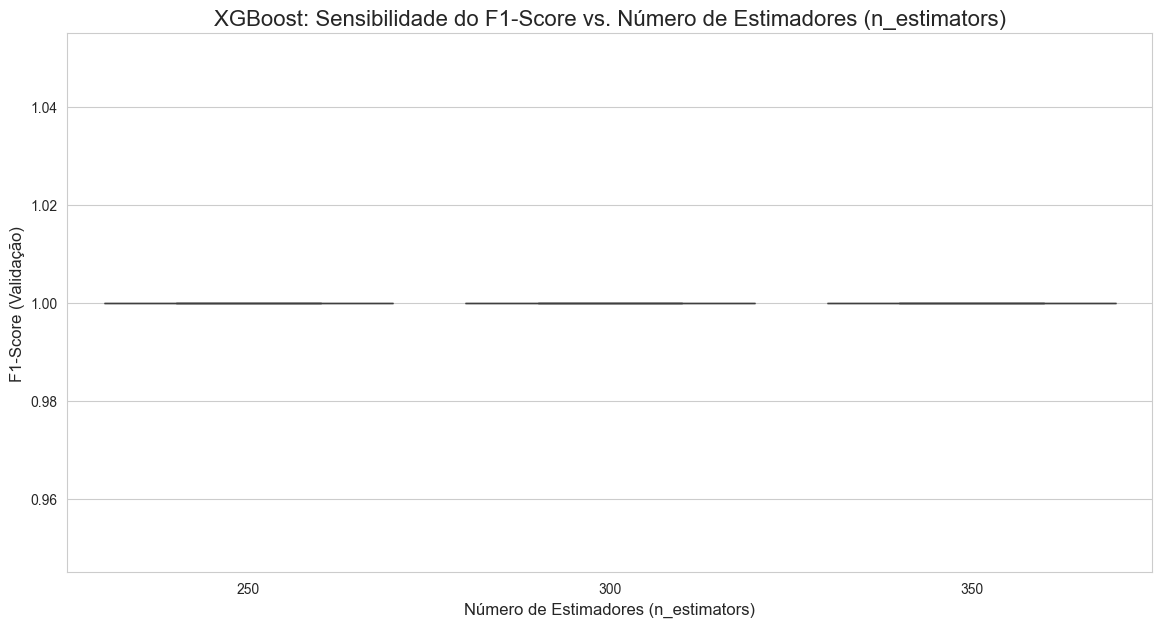

In [7]:
# Gráfico 1: Sensibilidade da Precisão (F1-Score)
plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='f1_score', data=results_df)
plt.title('XGBoost: Sensibilidade do F1-Score vs. Número de Estimadores (n_estimators)', fontsize=16)
plt.xlabel('Número de Estimadores (n_estimators)', fontsize=12)
plt.ylabel('F1-Score (Validação)', fontsize=12)
plt.show()

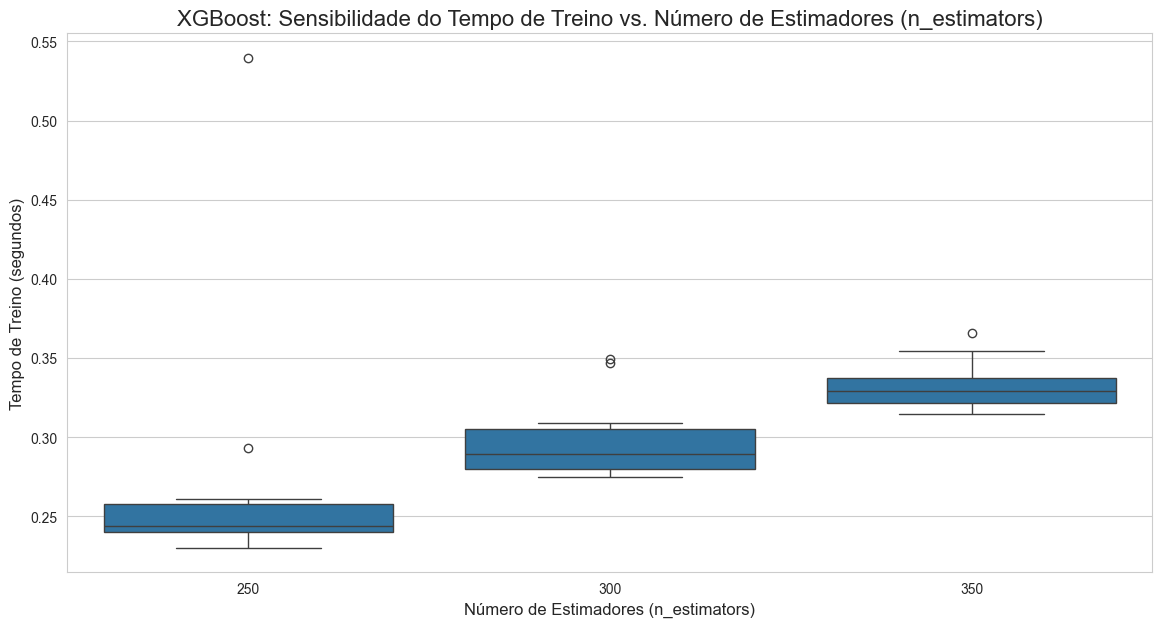

In [8]:
# Gráfico 2: Sensibilidade do Custo Computacional (Tempo de Treino)
plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='train_time', data=results_df)
plt.title('XGBoost: Sensibilidade do Tempo de Treino vs. Número de Estimadores (n_estimators)', fontsize=16)
plt.xlabel('Número de Estimadores (n_estimators)', fontsize=12)
plt.ylabel('Tempo de Treino (segundos)', fontsize=12)
plt.show()

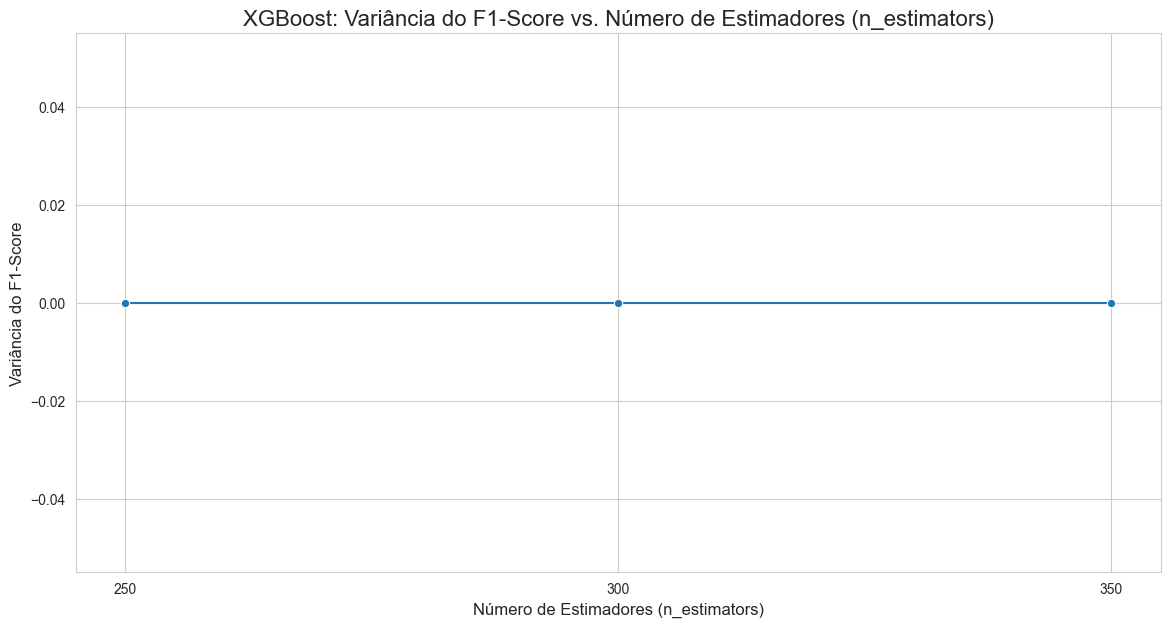

In [9]:
# Gráfico 3: Análise de Estabilidade (Variância)
variance_df = results_df.groupby('n_estimators')['f1_score'].var().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='n_estimators', y='f1_score', data=variance_df, marker='o')
plt.title('XGBoost: Variância do F1-Score vs. Número de Estimadores (n_estimators)', fontsize=16)
plt.xlabel('Número de Estimadores (n_estimators)', fontsize=12)
plt.ylabel('Variância do F1-Score', fontsize=12)
plt.xticks(param_grid['n_estimators'])
plt.show()

--- Otimização do Limiar de Decisão para XGBoost (Validation Set) ---
ROC AUC no conjunto de validação: 1.0000
PR AUC (Precision-Recall) no conjunto de validação: 1.0000
Melhor Limiar encontrado: 0.4897
F1-Score correspondente no conjunto de validação: 1.0000


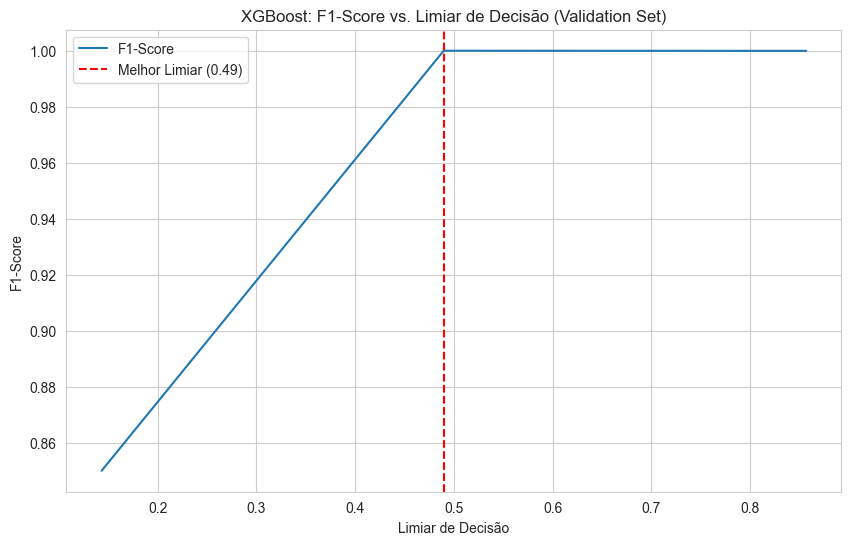

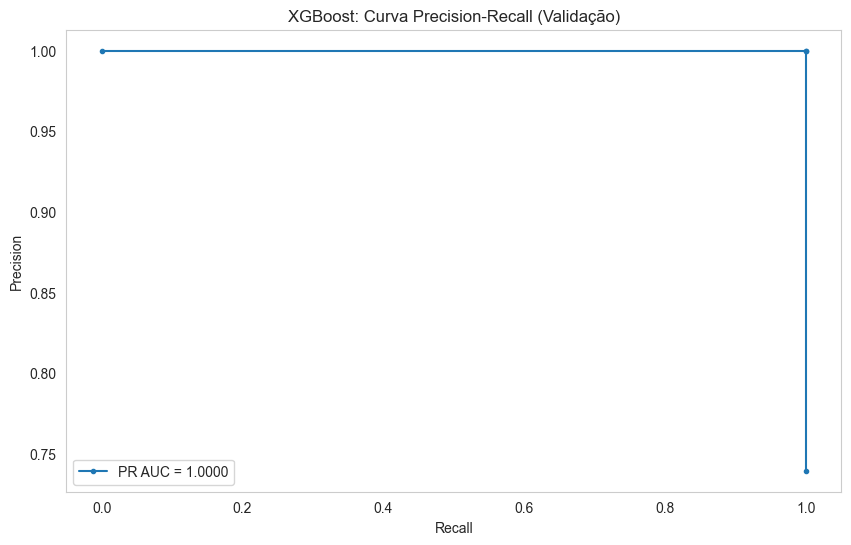

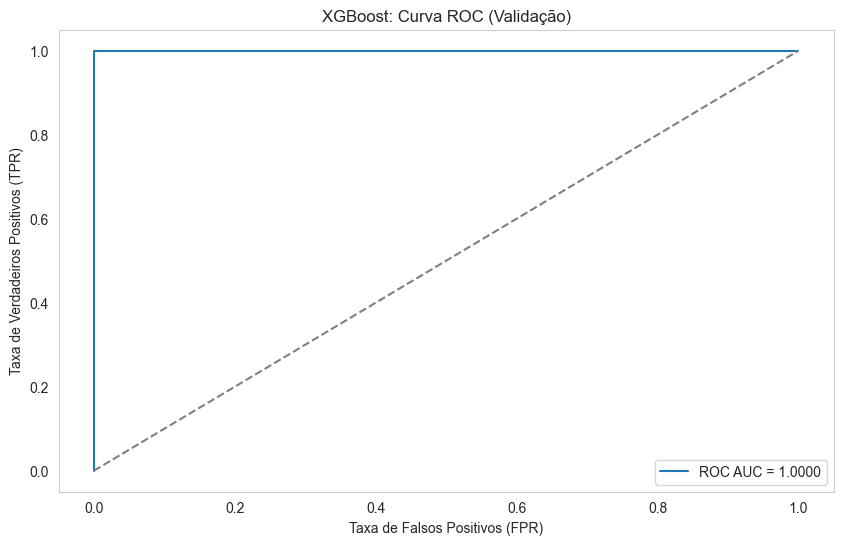

In [10]:
# Otimização do Limiar de Decisão
from sklearn.metrics import precision_recall_curve

print("--- Otimização do Limiar de Decisão para XGBoost (Validation Set) ---")

# Extrair os melhores hiperparâmetros encontrados
best_params_dict = {
    'n_estimators': int(best_params['n_estimators']),
    'max_depth': int(best_params['max_depth']),
    'learning_rate': best_params['learning_rate'],
    'gamma': best_params['gamma'],
    'scale_pos_weight': scale_pos_weight_value,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss' # <--- use_label_encoder removido
}

model_for_tuning = XGBClassifier(**best_params_dict)
model_for_tuning.fit(X_train_resampled, y_train_resampled)

# Obter as probabilidades de previsão para a classe positiva (Anomalia) no conjunto de validação
y_probs_val = model_for_tuning.predict_proba(X_val_pca)[:, 1]

# Calcular precisão, recall e limiares
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)

# Calcular F1-score para cada limiar
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# Calcular ROC AUC e PR AUC
roc_auc_val = roc_auc_score(y_val, y_probs_val)
pr_auc_val = auc(recall, precision)

print(f"ROC AUC no conjunto de validação: {roc_auc_val:.4f}")
print(f"PR AUC (Precision-Recall) no conjunto de validação: {pr_auc_val:.4f}")

# Encontrar o melhor limiar que maximiza o F1-score
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Melhor Limiar encontrado: {best_threshold:.4f}")
print(f"F1-Score correspondente no conjunto de validação: {best_f1:.4f}")

# Plotar a curva F1-Score vs. Limiar
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel("Limiar de Decisão")
plt.ylabel("F1-Score")
plt.title("XGBoost: F1-Score vs. Limiar de Decisão (Validation Set)")
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

# Curva Precision-Recall
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc_val:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost: Curva Precision-Recall (Validação)')
plt.legend()
plt.grid()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_probs_val)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_val:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('XGBoost: Curva ROC (Validação)') 
plt.legend()
plt.grid()
plt.show()

Formato do conjunto de treino final (X, y): (95029, 294), (95029,)
Distribuição final para treino com SMOTE: 1    70255
0    24774
Name: count, dtype: int64

Treinando o modelo final XGBoost...
Treino concluído.

--- Relatório de Classificação Final do XGBoost com Limiar Otimizado (Conjunto de Teste) ---
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     24780
    Anomalia       0.56      1.00      0.72     31523

    accuracy                           0.56     56303
   macro avg       0.28      0.50      0.36     56303
weighted avg       0.31      0.56      0.40     56303


ROC AUC (Teste): 0.5000
PR AUC (Teste): 0.7799
--- Matriz de Confusão do XGBoost com Limiar Otimizado (Conjunto de Teste) ---


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

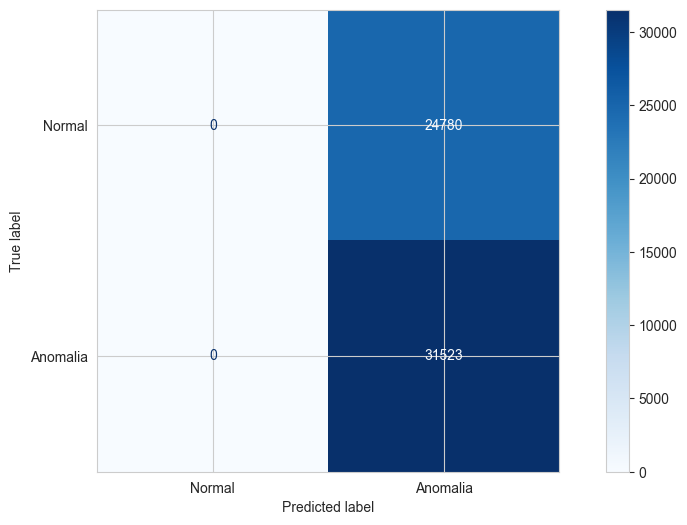

In [11]:
# Extrair os melhores parâmetros encontrados para o modelo final
final_params_dict = best_params_dict

# Combinar dados de treino e validação
X_train_full = sparse.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

# Opcional: Aplicar PCA se estiver usando
X_train_full_pca = X_train_full

print(f"Formato do conjunto de treino final (X, y): {X_train_full.shape}, {y_train_full.shape}")

# Aplicar SMOTE no conjunto de treino completo
smote_final = SMOTE(random_state=42)
#-- X_train_full_resampled, y_train_full_resampled = smote_final.fit_resample(X_train_full_pca, y_train_full)
X_train_full_resampled, y_train_full_resampled = X_train_full_pca, y_train_full
print("Distribuição final para treino com SMOTE:", pd.Series(y_train_full_resampled).value_counts())

# Instanciar o modelo final com os melhores hiperparâmetros
final_model = XGBClassifier(**final_params_dict)

# Treinar o modelo final
print("\nTreinando o modelo final XGBoost...")
final_model.fit(X_train_full_resampled, y_train_full_resampled)
print("Treino concluído.")

# Fazer previsões no conjunto de teste
y_pred_test_probs = final_model.predict_proba(X_test_pca)[:, 1]

# Aplicar o melhor limiar encontrado
y_pred_test_tuned = (y_pred_test_probs >= best_threshold).astype(int)
#----- y_pred_test_tuned = (y_pred_test_probs >= 0.90).astype(int)

# Avaliar o desempenho final
print("\n--- Relatório de Classificação Final do XGBoost com Limiar Otimizado (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_test_tuned, target_names=['Normal', 'Anomalia']))

# Métricas no conjunto de teste com limiar otimizado
roc_auc_test = roc_auc_score(y_test, y_pred_test_probs)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_pred_test_probs)
pr_auc_test = auc(recall_test, precision_test)

print(f"\nROC AUC (Teste): {roc_auc_test:.4f}")
print(f"PR AUC (Teste): {pr_auc_test:.4f}")

# Visualizar a Matriz de Confusão
print("--- Matriz de Confusão do XGBoost com Limiar Otimizado (Conjunto de Teste) ---")
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Normal', 'Anomalia'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.show()

C:\Users\GabrielMoreira\AppData\Local\Temp\ipykernel_32272\3110299572.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_probs, x='predicted_prob', hue='true_label', fill=True, common_norm=False)


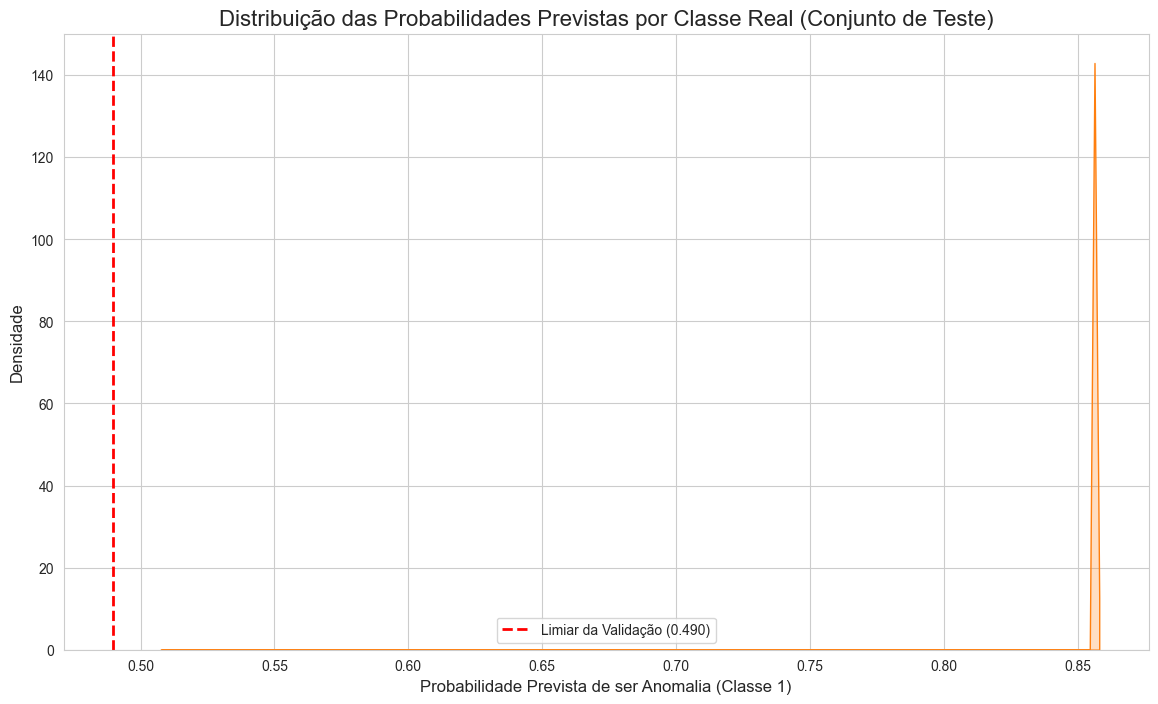

O limiar otimizado no conjunto de validação foi: 0.4897
No gráfico acima, você pode ver duas curvas de distribuição:
 - A curva para a Classe 'Normal (0)' mostra as probabilidades que o modelo deu para os casos que eram realmente normais.
 - A curva para a Classe 'Anomalia (1)' mostra as probabilidades para os casos que eram realmente anomalias.
Observe como a linha vermelha (seu limiar atual) está posicionada em relação a essas duas curvas.


In [12]:
# --- Célula 12: Diagnóstico da Distribuição de Probabilidades ---

# Criar um DataFrame para facilitar a plotagem com seaborn
df_probs = pd.DataFrame({
    'true_label': y_test,
    'predicted_prob': y_pred_test_probs
})

plt.figure(figsize=(14, 8))
# Plotar a distribuição de probabilidades para cada classe real
sns.kdeplot(data=df_probs, x='predicted_prob', hue='true_label', fill=True, common_norm=False)

# Legendas e títulos para clareza
plt.title('Distribuição das Probabilidades Previstas por Classe Real (Conjunto de Teste)', fontsize=16)
plt.xlabel('Probabilidade Prevista de ser Anomalia (Classe 1)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(title='Classe Real', labels=['Anomalia (1)', 'Normal (0)'])

# Adicionar uma linha vertical mostrando o limiar que foi usado
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=2, label=f'Limiar da Validação ({best_threshold:.3f})')
plt.legend()
plt.grid(True)
plt.show()

print(f"O limiar otimizado no conjunto de validação foi: {best_threshold:.4f}")
print("No gráfico acima, você pode ver duas curvas de distribuição:")
print(" - A curva para a Classe 'Normal (0)' mostra as probabilidades que o modelo deu para os casos que eram realmente normais.")
print(" - A curva para a Classe 'Anomalia (1)' mostra as probabilidades para os casos que eram realmente anomalias.")
print("Observe como a linha vermelha (seu limiar atual) está posicionada em relação a essas duas curvas.")

In [13]:
# --- Célula 13: Depuração Detalhada das Previsões e Limiar ---

print("--- INICIANDO DEPURAÇÃO ---")

# 1. Verificar o tipo e o formato do array de probabilidades
print(f"\nTipo da variável y_pred_test_probs: {type(y_pred_test_probs)}")
print(f"Formato (shape) do array: {y_pred_test_probs.shape}")

# 2. Olhar as estatísticas descritivas das probabilidades
# Isso DEVE corresponder ao que vimos no gráfico.
print("\nEstatísticas descritivas das probabilidades previstas:")
print(pd.Series(y_pred_test_probs).describe())

# 3. Inspecionar algumas das probabilidades reais
# Vamos ver se os valores são de fato floats entre 0 e 1.
print(f"\nAs 10 primeiras probabilidades previstas: \n{y_pred_test_probs[:10]}")

# 4. Re-aplicar o limiar e inspecionar o resultado ANTES do classification_report
manual_threshold = 0.90
print(f"\nAplicando manualmente o limiar de: {manual_threshold}")

# A operação booleana
comparison_result = y_pred_test_probs >= manual_threshold
print(f"\nAs 10 primeiras comparações (>= {manual_threshold}): \n{comparison_result[:10]}")

# O resultado convertido para inteiro
predictions_manual = comparison_result.astype(int)
print(f"\nAs 10 primeiras previsões finais (0 ou 1): \n{predictions_manual[:10]}")

# 5. Contar quantas previsões '0' e '1' foram feitas
# ESTE É O TESTE MAIS IMPORTANTE.
print("\n--- RESULTADO DA CONTAGEM ---")
try:
    counts = np.bincount(predictions_manual)
    print(f"Contagem de previsões: Classe 0 (Normal) = {counts[0]}, Classe 1 (Anomalia) = {counts[1]}")
except IndexError:
    print("Ocorreu um erro na contagem. Isso geralmente significa que apenas uma classe foi prevista.")
    print(f"Valores únicos nas previsões: {np.unique(predictions_manual)}")


print("\n--- FIM DA DEPURAÇÃO ---")

# 6. Gerar o relatório de classificação novamente com base nesta aplicação manual
print("\nGerando novo relatório de classificação com base nos valores depurados:")
print(classification_report(y_test, predictions_manual, target_names=['Normal', 'Anomalia']))

--- INICIANDO DEPURAÇÃO ---

Tipo da variável y_pred_test_probs: <class 'numpy.ndarray'>
Formato (shape) do array: (56303,)

Estatísticas descritivas das probabilidades previstas:
count    56303.000000
mean         0.856891
std          0.002076
min          0.508564
25%          0.856903
50%          0.856903
75%          0.856903
max          0.856903
dtype: float64

As 10 primeiras probabilidades previstas: 
[0.8569029 0.8569029 0.8569029 0.8569029 0.8569029 0.8569029 0.8569029
 0.8569029 0.8569029 0.8569029]

Aplicando manualmente o limiar de: 0.9

As 10 primeiras comparações (>= 0.9): 
[False False False False False False False False False False]

As 10 primeiras previsões finais (0 ou 1): 
[0 0 0 0 0 0 0 0 0 0]

--- RESULTADO DA CONTAGEM ---
Ocorreu um erro na contagem. Isso geralmente significa que apenas uma classe foi prevista.
Valores únicos nas previsões: [0]

--- FIM DA DEPURAÇÃO ---

Gerando novo relatório de classificação com base nos valores depurados:
              prec

C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif